# SGT_K — multi-way branching

By default an SGT node routes samples into **2** children (a binary outer tree). The `num_partitions` knob is the branching factor **K**: set it above 2 and each node routes into K children at once. This is the SGT_K generalization. Multi-way branching lets a tree express multi-region structure with **less depth** — a shallower, more compact, more interpretable tree.

## When does K > 2 help?

A node can only route into K children if its inner *shape function* produces at least K bins, so K > 2 needs enough inner capacity (`inner_max_depth` / `inner_max_leaf_nodes`) to feed the extra branches. Given that, a wide split captures a many-region feature in a single level where a binary tree would need several.

We use a single informative feature split into four bands (four classes); the second feature is noise. `inner_max_depth=2` lets each node form up to four bins.

In [1]:
import numpy as np
from sgtlearn import SGTClassifier

rng = np.random.RandomState(0)
n = 2000
x0 = rng.uniform(0, 4, n)
y = np.clip(x0.astype(int), 0, 3)          # bands [0,1)->0, [1,2)->1, [2,3)->2, [3,4)->3
X = np.column_stack([x0, rng.uniform(0, 1, n)])

for k in (2, 4):
    m = SGTClassifier(max_depth=1, num_partitions=k, inner_max_depth=2, random_state=0).fit(X, y)
    print(f"num_partitions={k}, max_depth=1: acc={m.score(X, y):.3f}  nodes={m.tree_export()['num_nodes']}")

num_partitions=2, max_depth=1: acc=0.512  nodes=3
num_partitions=4, max_depth=1: acc=0.761  nodes=4


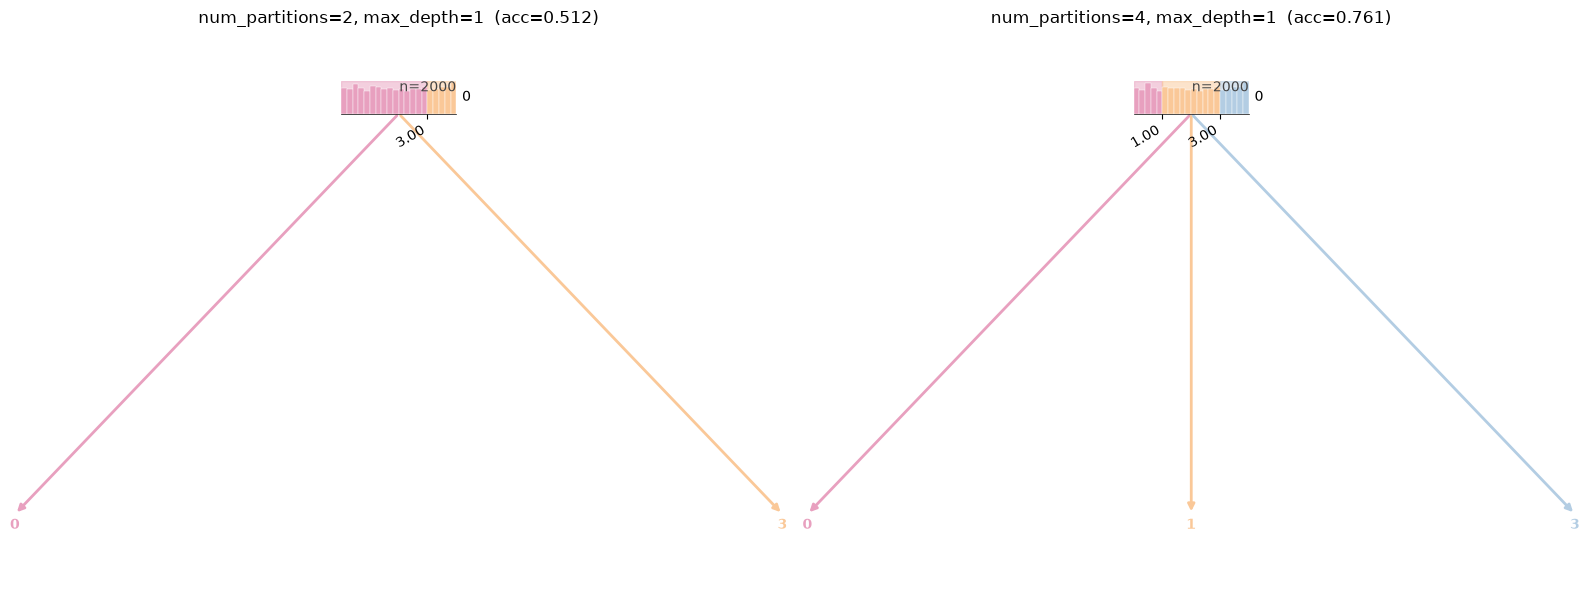

In [2]:
import matplotlib.pyplot as plt
from sgtlearn import plot_tree

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, k in zip(axes, (2, 4)):
    m = SGTClassifier(max_depth=1, num_partitions=k, inner_max_depth=2, random_state=0).fit(X, y)
    plot_tree(m, X=X, ax=ax)
    ax.set_title(f"num_partitions={k}, max_depth=1  (acc={m.score(X, y):.3f})")
plt.tight_layout()
plt.show()

## What to notice

At a single outer level (`max_depth=1`), `num_partitions=4` routes the four bands across its wider set of children and separates the classes far better than the binary node, which can only make a 2-way cut. Multi-way branching captured the four-region structure in **one** split.

In [3]:
# How deep must a binary tree go to match K=4's single-level accuracy?
for md in (1, 2, 3):
    m = SGTClassifier(max_depth=md, num_partitions=2, inner_max_depth=2, random_state=0).fit(X, y)
    print(f"num_partitions=2, max_depth={md}: acc={m.score(X, y):.3f}  nodes={m.tree_export()['num_nodes']}")

num_partitions=2, max_depth=1: acc=0.512  nodes=3
num_partitions=2, max_depth=2: acc=0.761  nodes=5
num_partitions=2, max_depth=3: acc=1.000  nodes=7


The binary tree only matches `num_partitions=4`'s depth-1 accuracy at `max_depth=2` — a deeper tree with more nodes. So K is a lever for **compactness**: set it near the number of natural regions in a feature. Too-large K on simple structure just adds empty branches, and K only pays off when the inner shape function ([`inner_max_depth`](shape-functions.ipynb)) can produce enough bins to feed it.

`num_partitions` also sets the outgoing branches for a bivariate router; see the three-way [S²GT example](bivariate-branching.ipynb). See [Structure vs. accuracy](structure-and-accuracy.ipynb) for choosing K on real data with a train/test split.